#Assignment 3 : Linear Regression
###Author : Poorvi Raut

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime  # Import the datetime module

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/DS_Assignment3/cleaned_house_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MLS               4407 non-null   int64  
 1   sold_price        4407 non-null   float64
 2   zipcode           4407 non-null   int64  
 3   longitude         4407 non-null   float64
 4   latitude          4407 non-null   float64
 5   lot_acres         4407 non-null   float64
 6   taxes             4407 non-null   float64
 7   year_built        4404 non-null   object 
 8   bedrooms          4407 non-null   int64  
 9   bathrooms         4407 non-null   float64
 10  sqrt_ft           4407 non-null   float64
 11  garage            4407 non-null   float64
 12  kitchen_features  4407 non-null   object 
 13  fireplaces        4407 non-null   float64
 14  floor_covering    4407 non-null   object 
 15  HOA               4407 non-null   float64
 16  price_per_sqft    4407 non-null   float64


In [ ]:
df

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,...,garage,kitchen_features,fireplaces,floor_covering,HOA,price_per_sqft,tax_price_ratio,HOA_category,price_category,tax_category
0,21306357,3411450.0,85750,-110.813768,32.285162,3.21,15393.00,1995-01-01,4,6.0,...,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Carpet, Concrete",55.00,533.372420,0.004512,Low,19,1
1,21528016,3250000.0,85718,-110.910593,32.339090,1.67,27802.84,1999-01-01,3,4.0,...,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Natural Stone, Wood, Other",422.00,475.007308,0.008555,High,19,8
2,21610478,2400000.0,85712,-110.883315,32.261069,2.10,19038.42,2001-01-01,9,8.0,...,4.0,"Dishwasher, Garbage Disposal, Oven",6.0,"Carpet, Natural Stone, Wood, Other",0.00,199.584200,0.007933,No HOA,9,6
3,21211741,2500000.0,85750,-110.861002,32.331603,1.07,21646.00,2011-01-01,6,8.0,...,4.0,"Compactor, Dishwasher, Freezer, Garbage Dispos...",5.0,"Carpet, Natural Stone, Wood",220.00,280.237642,0.008658,Medium,18,8
4,21812010,3250000.0,85750,-110.837950,32.327575,3.53,18936.11,2007-01-01,5,6.0,...,3.0,"Dishwasher, Double Sink, Electric Range, Freez...",2.0,"Carpet, Concrete",141.67,501.543210,0.005826,Medium,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,3056450,525000.0,85614,-110.980945,31.824287,3.01,5122.84,2007-01-01,3,3.0,...,3.0,"Dishwasher, Garbage Disposal, Gas Range, Refri...",1.0,"Concrete, Other: Cork",37.00,141.267002,0.009758,Low,0,12
4403,21908358,565000.0,85750,-110.820216,32.307646,0.83,4568.71,1986-01-01,4,3.0,...,2.0,"Dishwasher, Double Sink, Electric Range, Garba...",2.0,"Carpet, Mexican Tile",6.00,200.853182,0.008086,Low,9,6
4404,21909379,535000.0,85718,-110.922291,32.317496,0.18,4414.00,2002-01-01,3,2.0,...,2.0,"Dishwasher, Double Sink, Electric Range, Garba...",1.0,Ceramic Tile,198.00,254.036087,0.008250,Medium,16,7
4405,21908591,550000.0,85750,-110.858556,32.316373,1.42,4822.01,1990-01-01,4,3.0,...,3.0,"Dishwasher, Double Sink, Electric Range, Garba...",1.0,"Carpet, Ceramic Tile",43.00,237.273512,0.008767,Low,15,8


In [ ]:
# Checking for missing values
print(df.isnull().values.any())

True


In [ ]:
#Filling missing values
#All numerical value with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

#All categorical values with mode
df.fillna(df.mode().iloc[0], inplace=True)

In [ ]:
# Creating a price_category column based on price_per_sqft
# Create 20 equal-width bins for price_per_sqft
df["price_category"] = pd.qcut(df["price_per_sqft"], q=20, labels=range(0, 20))

# Display the updated dataset with the new column
df[["price_per_sqft", "price_category"]].head()

,price_per_sqft,price_category
0,533.372420,19
1,475.007308,19
2,199.584200,9
3,280.237642,18
4,501.543210,19


In [ ]:
# Creating a tax_category column based on tax_price_ratio
# Create 20 equal-width bins for price_per_sqft
df["tax_category"] = pd.qcut(df["tax_price_ratio"], q=20, labels=range(0, 20))

# Display the updated dataset with the new column
df[["tax_price_ratio", "tax_category"]].head()

,tax_price_ratio,tax_category
0,0.004512,1
1,0.008555,8
2,0.007933,6
3,0.008658,8
4,0.005826,2


In [ ]:
df

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,...,garage,kitchen_features,fireplaces,floor_covering,HOA,price_per_sqft,tax_price_ratio,HOA_category,price_category,tax_category
0,21306357,3411450.0,85750,-110.813768,32.285162,3.21,15393.00,1995-01-01,4,6.0,...,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Carpet, Concrete",55.00,533.372420,0.004512,Low,19,1
1,21528016,3250000.0,85718,-110.910593,32.339090,1.67,27802.84,1999-01-01,3,4.0,...,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Natural Stone, Wood, Other",422.00,475.007308,0.008555,High,19,8
2,21610478,2400000.0,85712,-110.883315,32.261069,2.10,19038.42,2001-01-01,9,8.0,...,4.0,"Dishwasher, Garbage Disposal, Oven",6.0,"Carpet, Natural Stone, Wood, Other",0.00,199.584200,0.007933,No HOA,9,6
3,21211741,2500000.0,85750,-110.861002,32.331603,1.07,21646.00,2011-01-01,6,8.0,...,4.0,"Compactor, Dishwasher, Freezer, Garbage Dispos...",5.0,"Carpet, Natural Stone, Wood",220.00,280.237642,0.008658,Medium,18,8
4,21812010,3250000.0,85750,-110.837950,32.327575,3.53,18936.11,2007-01-01,5,6.0,...,3.0,"Dishwasher, Double Sink, Electric Range, Freez...",2.0,"Carpet, Concrete",141.67,501.543210,0.005826,Medium,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,3056450,525000.0,85614,-110.980945,31.824287,3.01,5122.84,2007-01-01,3,3.0,...,3.0,"Dishwasher, Garbage Disposal, Gas Range, Refri...",1.0,"Concrete, Other: Cork",37.00,141.267002,0.009758,Low,0,12
4403,21908358,565000.0,85750,-110.820216,32.307646,0.83,4568.71,1986-01-01,4,3.0,...,2.0,"Dishwasher, Double Sink, Electric Range, Garba...",2.0,"Carpet, Mexican Tile",6.00,200.853182,0.008086,Low,9,6
4404,21909379,535000.0,85718,-110.922291,32.317496,0.18,4414.00,2002-01-01,3,2.0,...,2.0,"Dishwasher, Double Sink, Electric Range, Garba...",1.0,Ceramic Tile,198.00,254.036087,0.008250,Medium,16,7
4405,21908591,550000.0,85750,-110.858556,32.316373,1.42,4822.01,1990-01-01,4,3.0,...,3.0,"Dishwasher, Double Sink, Electric Range, Garba...",1.0,"Carpet, Ceramic Tile",43.00,237.273512,0.008767,Low,15,8


In [ ]:
# Save the cleaned dataset
df1=df.to_csv("cleaned_house_data_1.csv", index=False)
print("Cleaned dataset saved as cleaned_house_data_1.csv")

Cleaned dataset saved as cleaned_house_data_1.csv


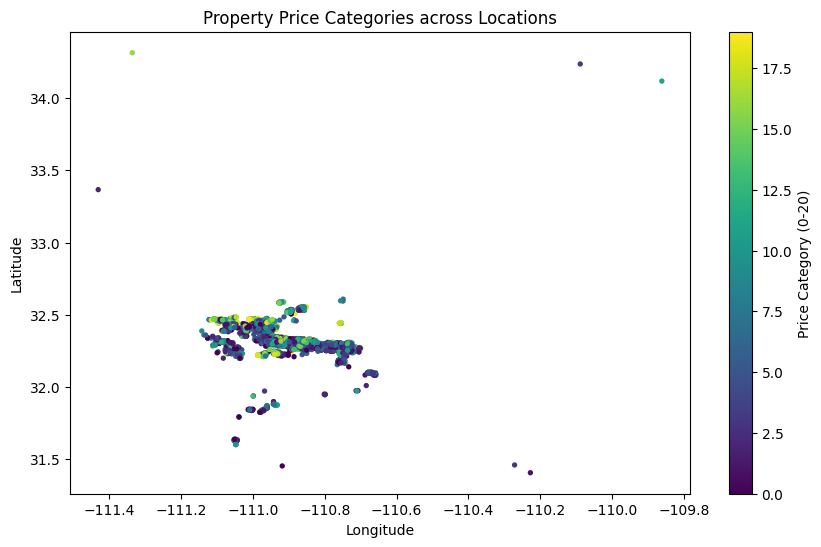

In [ ]:
#Scatter plot for Longitude and Latitude vs price_category
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["longitude"], df["latitude"], c=df["price_category"].astype(int), cmap="viridis",s=8)
plt.colorbar(scatter, label="Price Category (0-20)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Price Categories across Locations")
plt.show()

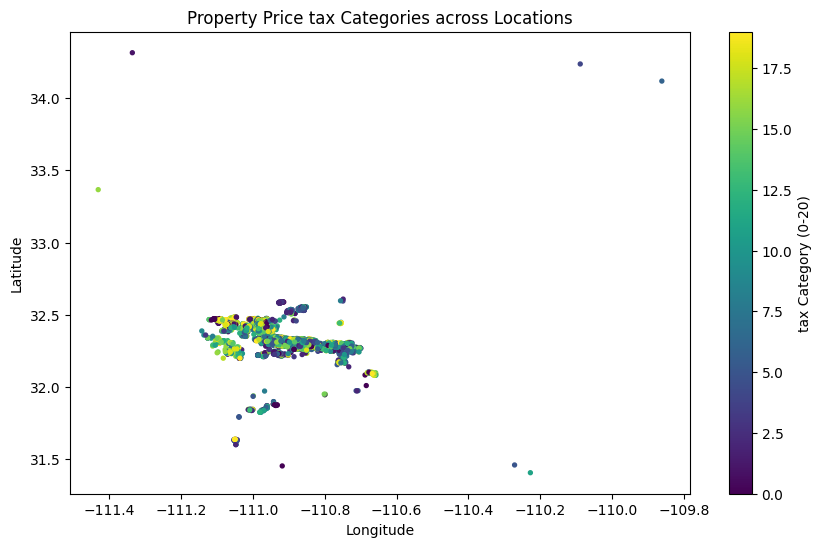

In [ ]:
#Scatter plot for Longitude and Latitude vs tax_category
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["longitude"], df["latitude"], c=df["tax_category"].astype(int), cmap="viridis",s=8)
plt.colorbar(scatter, label="tax Category (0-20)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Price tax Categories across Locations")
plt.show()

## Geographic Encoder using KNN Classifier using Longitude and latitude and price category and tax category

In [ ]:
class KNNClassifier():
  def fit(self,X,y):
    self.X=X
    self.y=y

  def predict(self,X,K,epsilon=1e-3):
    N=len(X)
    y_hat=np.zeros(N)

    for i in range(N):
      dist2 = np.sum((self.X-X[i])**2, axis=1)
      idxt = np.argsort(dist2)[:K]
      gamma_k = 1/(np.sqrt(dist2[idxt]+epsilon))

      y_hat[i] =np.bincount(self.y[idxt],weights =gamma_k).argmax()

    return y_hat

In [ ]:
knn_instance=KNNClassifier()

In [ ]:
X = df[["longitude", "latitude"]].values  # Convert to NumPy array

# Convert price_category_20bins to numeric labels
y = df["price_category"].astype(int).values  # Convert categories to integer labels

In [ ]:
knn_instance.fit(X,y)

In [ ]:
y_hat=knn_instance.predict(X,K=5) #adjusting value of K can help to train model better

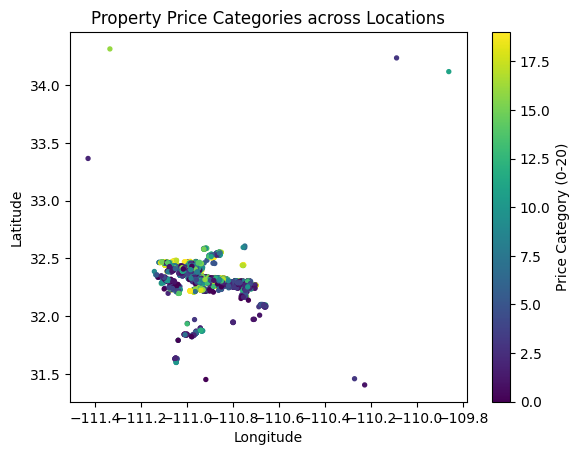

In [ ]:
plt.figure()
z=plt.scatter(X[:,0],X[:,1],c=y_hat,s=8)
plt.colorbar(z, label="Price Category (0-20)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Price Categories across Locations")
plt.show()

In [ ]:
def accuracy(y,y_hat):
  return np.mean(y==y_hat)

In [ ]:
accuracy(y,y_hat)

np.float64(0.7004765146358066)

Text(0.5, 47.7222222222222, 'Predicted label')

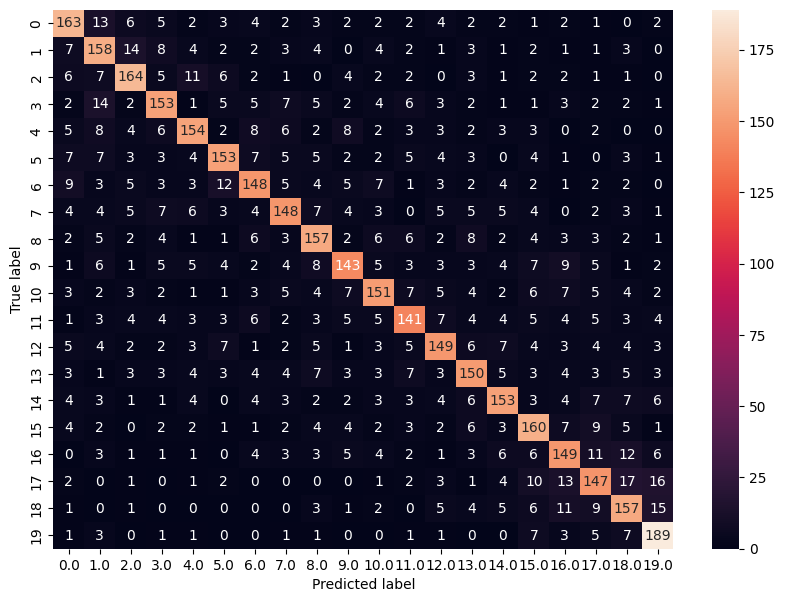

In [ ]:
#plotting the confusion matrix for testing data
plt.figure(figsize=(10,7))
y_actu = pd.Series(y, name='Actual')
y_pred = pd.Series(y_hat, name='Predicted')
cm = pd.crosstab(y_actu, y_pred)
ax = sns.heatmap(cm, annot=True, fmt="d")
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [ ]:
X1= X
Y1= df["tax_category"].astype(int).values  # Convert categories to integer labels

In [ ]:
knn_instance.fit(X1,Y1)

In [ ]:
y_hat_1=knn_instance.predict(X1,K=5) #adjusting value of K can help to train model better

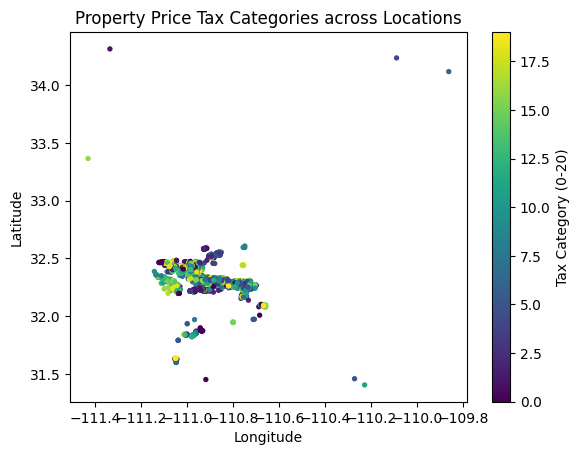

In [ ]:
plt.figure()
z=plt.scatter(X1[:,0],X1[:,1],c=y_hat_1,s=8)
plt.colorbar(z, label="Tax Category (0-20)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Price Tax Categories across Locations")
plt.show()

In [ ]:
accuracy(Y1,y_hat_1)

np.float64(0.6789199001588382)

Text(0.5, 47.7222222222222, 'Predicted label')

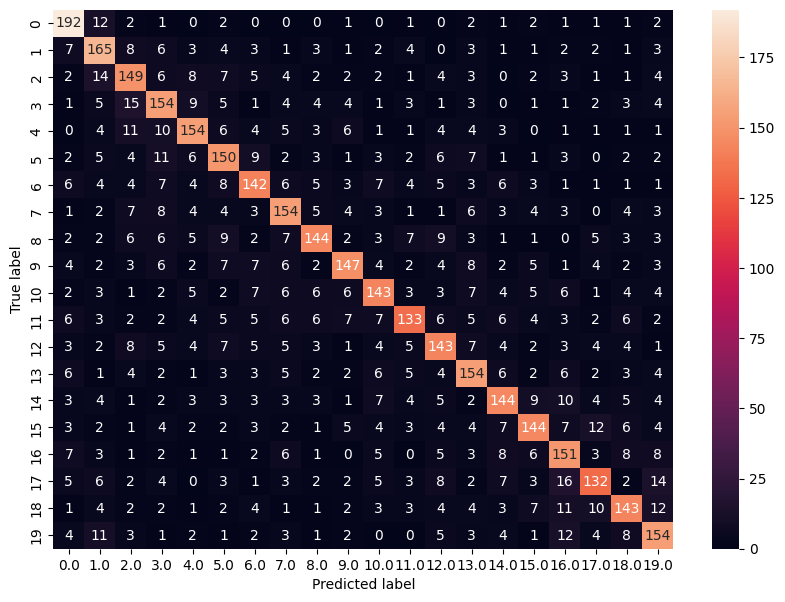

In [ ]:
#plotting the confusion matrix for testing  for tax category data
plt.figure(figsize=(10,7))
y_actu = pd.Series(Y1, name='Actual')
y_pred = pd.Series(y_hat_1, name='Predicted')
cm = pd.crosstab(y_actu, y_pred)
ax = sns.heatmap(cm, annot=True, fmt="d")
plt.ylabel('True label')
plt.xlabel('Predicted label')

## Multivariate Linear Regression for target feature : tax_price_ratio

In [ ]:
#OLS regressor with Gradient Descent
#Helpful Functions

def MAE(Y,Y_hat):
  return np.sum(np.abs((Y-Y_hat)))/len(Y)

def R2(Y,Y_hat):
  N=len(Y)
  return 1-((np.sum((Y-Y_hat)**2)/np.sum((Y_hat-np.mean(Y))**2)))  #changing from Y_hat-np.sum(Y)  to Y-np.sum(Y)

def OLS(Y,Y_hat,N):
  return((1/(2*N))*np.sum((Y-Y_hat)**2))


## Multivariate Linear Regressor Function

In [ ]:
class MVLinearRegression():

  def fit(self,X,y,eta=1e-4,epochs=2000,show_curve=True):
    # epochs= total number iterations
    epochs=int(epochs)
    N,D=X.shape
    Y=y

    #Begin Optimization with SGD
    self.W=np.random.randn(D) # Initialize weights with the correct number of features
    self.J=np.zeros(epochs)
    # Start Gradient Descent Progression
    for epoch in range(epochs):
      Y_hat=self.predict(X)
      self.J[epoch]=OLS(Y,Y_hat,N)
      #Weight Update rule
      self.W -= eta*(1/N)*(X.T@(Y_hat-Y)) #Gradient
    if show_curve:
      plt.figure()
      plt.plot(self.J)
      plt.xlabel("epochs")
      plt.ylabel("J")
      plt.title("Training Curve")

  def predict(self,X):
    return X@self.W


'''
  def predict(self,X):
    # Check if the number of features in X matches the number of weights
    if X.shape[1] != self.W.shape[0]:
      raise ValueError(f"Input data has {X.shape[1]} features, but model expects {self.W.shape[0]} features.")
    return X@self.W
    '''

'\n  def predict(self,X):\n    # Check if the number of features in X matches the number of weights\n    if X.shape[1] != self.W.shape[0]:\n      raise ValueError(f"Input data has {X.shape[1]} features, but model expects {self.W.shape[0]} features.")\n    return X@self.W\n    '

In [ ]:
df.columns

Index(['MLS', 'sold_price', 'zipcode', 'longitude', 'latitude', 'lot_acres',
       'taxes', 'year_built', 'bedrooms', 'bathrooms', 'sqrt_ft', 'garage',
       'kitchen_features', 'fireplaces', 'floor_covering', 'HOA',
       'price_per_sqft', 'tax_price_ratio', 'HOA_category', 'price_category',
       'tax_category'],
      dtype='object')

In [ ]:
X_raw = df[['tax_price_ratio','sold_price','sqrt_ft','taxes']].to_numpy()

In [ ]:
#  Standardize X
# 1. Min-Max Scaling
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

#X_min = X.min(axis=0)
#X_max = X.max(axis=0)

#X_scaled = (X - X_min) / (X_max - X_min)

In [ ]:
# 2. Split into target (y) and features (X)
y = X_scaled[:, 0]        # tax_price_ratio
X = X_scaled[:, 1:]       # other features

In [ ]:
X_scaled

array([[3.84168242e-04, 1.00000000e+00, 4.55345912e-01, 1.26016418e-03],
       [7.28354824e-04, 9.50207405e-01, 4.98500242e-01, 2.27610882e-03],
       [6.75393479e-04, 6.88059955e-01, 1.00000000e+00, 1.55860034e-03],
       ...,
       [7.02450536e-04, 1.12877608e-01, 4.02515723e-02, 3.61356766e-04],
       [7.46453259e-04, 1.17503739e-01, 6.07643928e-02, 3.94758935e-04],
       [9.01396944e-04, 1.17503739e-01, 1.96806967e-01, 4.76700307e-04]])

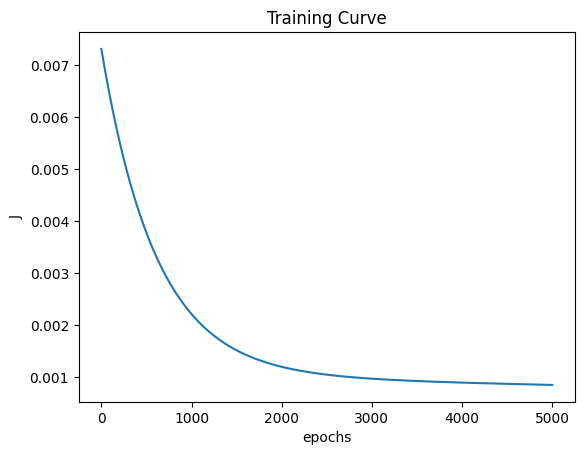

In [ ]:
my_reg=MVLinearRegression()
my_reg.fit(X_scaled,y,eta=1e-2,epochs=5000) #tweaking the values of eta and epochs for evaluation

In [ ]:
X_test_raw = np.array([
    [0,2400000, 6356,22655.99],   # House 1 (15)
    [0,3000000, 7756, 24040.26],   # House 2 (10)
    [0,1800000, 5100,21010.75]])  # House 3  (20)


In [ ]:
# Fix: Include all 5 features for scaling
#X_min = X_raw.min(axis=0)
#X_max =  X_raw.max(axis=0)

In [ ]:
X_test_scaled = (X_test_raw - X_min[None,:]) / (X_max[None,:] - X_min[None,:])

In [ ]:
# 6. Predict
y_preds = my_reg.predict(X_test_scaled)

In [ ]:
# 7. Assume true target values (replace with real ones if you have)
y_true = np.array([0.09439, 0.008, 0.0027])

In [ ]:
# 8. Evaluation
mae = MAE(y_true, y_preds)
r2 = R2(y_true, y_preds)
ols = OLS(y_true, y_preds, len(y_true))

In [ ]:
# 9. Print results
print("\n--- Predictions ---")
for i, pred in enumerate(y_preds):
    print(f"House {i+1} Predicted Tax Price Ratio: {round(pred, 5)}")

print("\n--- Evaluation on Test Data ---")
print("True Tax Price Ratios:", y_true)
print("Predicted Tax Price Ratios:", np.round(y_preds, 2))
print("Mean Prediction:", round(np.mean(y_preds), 2))
print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 2))
print("OLS Loss:", round(ols, 2))


--- Predictions ---
House 1 Predicted Tax Price Ratio: 0.11398
House 2 Predicted Tax Price Ratio: 0.13916
House 3 Predicted Tax Price Ratio: 0.08343

--- Evaluation on Test Data ---
True Tax Price Ratios: [0.09439 0.008   0.0027 ]
Predicted Tax Price Ratios: [0.11 0.14 0.08]
Mean Prediction: 0.11
MAE: 0.08
R² Score: -0.24
OLS Loss: 0.0


In [ ]:
corr_df = pd.DataFrame(X_scaled)   # Convert corr_df to a pandas DataFrame
# Predict tax_price_ratio for the entire dataset (X)
y_pred_all = my_reg.predict(X_scaled)
corr_df['tax_price_ratio'] = y_pred_all  # Assign predictions for all data points # Assign y_pred values, adjust size if needed

In [ ]:
corr_matrix = corr_df.corr()

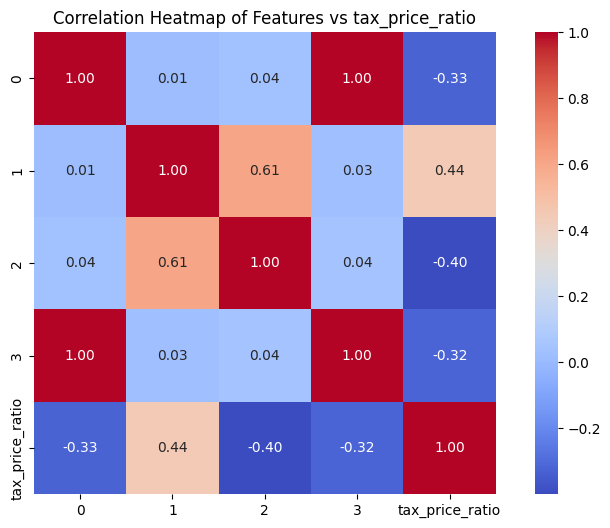

In [ ]:
# Correlation Heatmap
#numeric_data = df.select_dtypes(include=np.number)
#correlation = numeric_data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Heatmap of Features vs tax_price_ratio")
plt.show()